## HateXplain - 3 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import torch
import numpy as np

from datasets import load_dataset

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)


In [6]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [7]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [9]:
task_config = {
    "hate_speech": {"type": "hate_speech"},
    "women": {"type": "group_hate", "group": "Women"},
    "homosexual": {"type": "group_hate", "group": "Homosexual"},
    #"indigenous": {"type": "group_hate", "group": "Indigenous"},
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [00:48<00:00,  9.94it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [10]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

11:33:34 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
11:33:34 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 100.85it/s]


Epoch 1 - Average loss: 0.2449


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 109.02it/s]


Epoch 2 - Average loss: 0.2397


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 110.71it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 102.01it/s]


Epoch 2 - Average loss: 0.1133


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 107.80it/s]


Epoch 3 - Average loss: 0.1142
new solution added [0.58907966 0.34996489 0.26536566]
solution dominated [0.589197   0.35002877 0.26553424]
solution dominated [0.58963294 0.35000825 0.26565607]


11:56:39 | DEBUG | machinemoo | Calculated weights: [1.82275034e-01 3.44001870e-07 8.17724622e-01]
11:56:39 | DEBUG | machinemoo | Importance: 4.5819881995146083e-05
11:56:39 | DEBUG | machinemoo | Global lower bound (y*): [0.58874719 0.34973899 0.26522934]
11:56:39 | DEBUG | machinemoo | Iteration 150
11:56:39 | DEBUG | machinemoo | Solutions list: [array([0.58907966, 0.34996489, 0.26536566]), array([0.58894446, 0.35011872, 0.266487  ]), array([0.58947697, 0.35032105, 0.26527921]), array([0.58969125, 0.35003307, 0.26522934]), array([0.58936315, 0.34988237, 0.26569921]), array([0.58874719, 0.35032185, 0.26647015]), array([0.58883842, 0.3502893 , 0.26592475]), array([0.58899344, 0.34973899, 0.26581554]), array([0.58901177, 0.35043565, 0.26561141]), array([0.58890841, 0.35130044, 0.2659225 ]), array([0.58894444, 0.35081799, 0.26563489])]


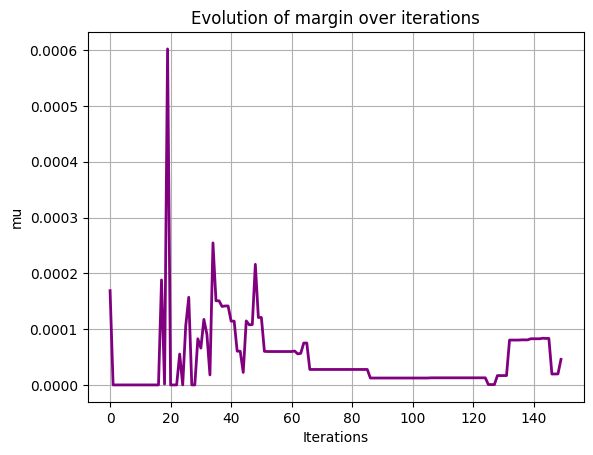

11:56:39 | INFO | machinemoo | Fit runtime: 1385.24 seconds


In [11]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

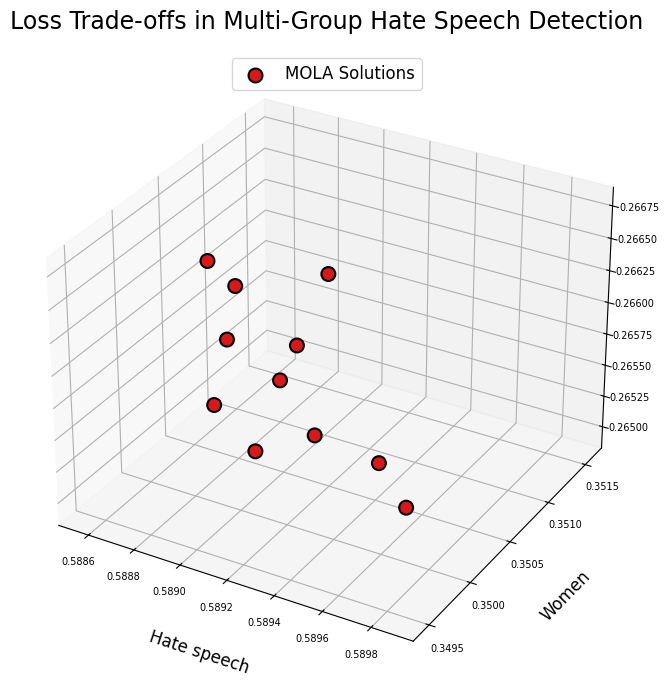

In [22]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=12,
            figsize=(10,7),
            save_path='images/3_objs_mola.pdf'
            )

11:56:39 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
11:56:39 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 107.06it/s]


Epoch 1 - Average loss: 0.2266


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 103.40it/s]


Epoch 2 - Average loss: 0.2231


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 101.15it/s]


...

Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 97.16it/s] 


Epoch 3 - Average loss: 0.2030


12:20:14 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [0.3738586  0.23435864 0.17959725]


new solution dominated [0.58917824 0.3911613  0.29253226]


12:20:14 | DEBUG | machinemoo | Calculated weights: [1. 0. 0.]
12:20:14 | DEBUG | machinemoo | Importance: 0.2148795268665339
12:20:14 | DEBUG | machinemoo | Global lower bound (y*): [0.3738586  0.23435864 0.17959725]
12:20:14 | DEBUG | machinemoo | Iteration 150
12:20:14 | DEBUG | machinemoo | Solutions list: [array([0.58873814, 0.39118818, 0.29244032]), array([0.58895095, 0.38993413, 0.29111277]), array([0.58885501, 0.39006684, 0.29093198]), array([0.58924789, 0.38844226, 0.29009852]), array([0.58937037, 0.38815491, 0.28957019]), array([0.58915732, 0.38849796, 0.29007082]), array([0.58952257, 0.38881949, 0.28935995]), array([0.58897735, 0.38882325, 0.28922641]), array([0.58925639, 0.38851123, 0.28937614]), array([0.58934325, 0.38830117, 0.28937076]), array([0.58962585, 0.38815413, 0.2899062 ]), array([0.59000308, 0.38807745, 0.28902971]), array([0.5906019 , 0.38825369, 0.28894546]), array([0.59044855, 0.38804239, 0.28974708]), array([0.59047499, 0.3882632 , 0.28893753]), array([0.590

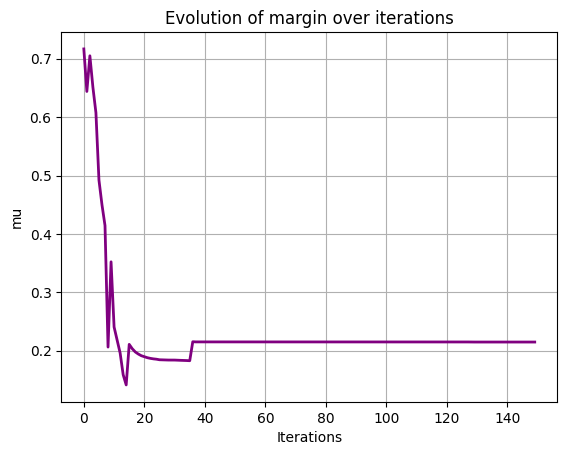

12:20:14 | INFO | machinemoo | Fit runtime: 1414.46 seconds


In [13]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

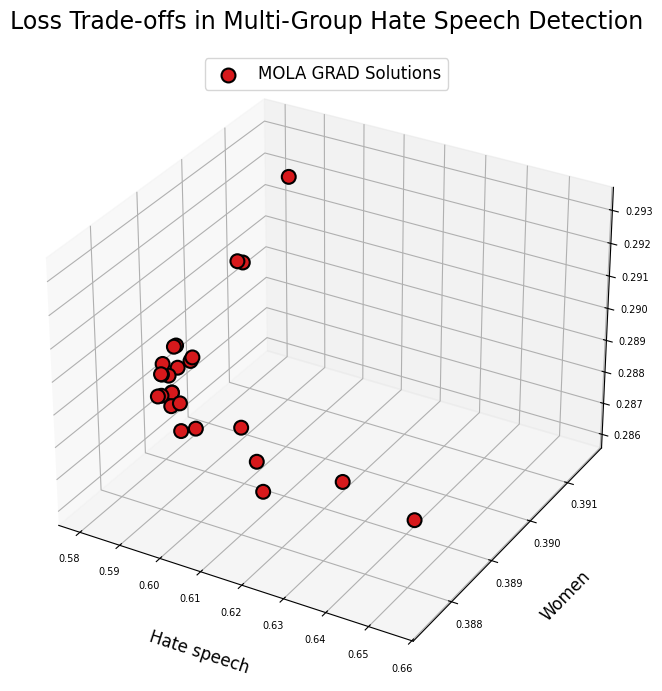

In [24]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'mola_grad': results['mola_grad']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=12,
            figsize=(10,7),
            save_path='images/3_objs_mola_grad.pdf'
            )

### Random Weights

In [ ]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

12:20:14 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeGap', 'nodeTimeLimit', 'targetGap'}
12:20:14 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
12:20:14 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/3:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 92.77it/s]


Epoch 1 - Average loss: 0.2413


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 94.95it/s] 


Epoch 2 - Average loss: 0.2373


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 97.56it/s] 


Epoch 2 - Average loss: 0.1457


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 94.84it/s] 


Epoch 3 - Average loss: 0.1455


12:43:52 | DEBUG | machinemoo | 150th solution


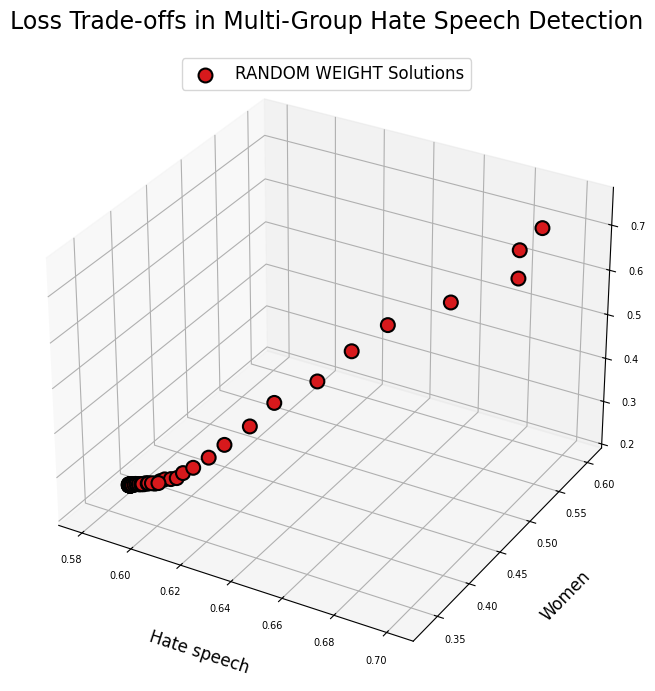

In [26]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'random_weight': results['random_weight_grad']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=12,
            figsize=(10,7),
            save_path='images/3_objs_rw.pdf'
            )

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

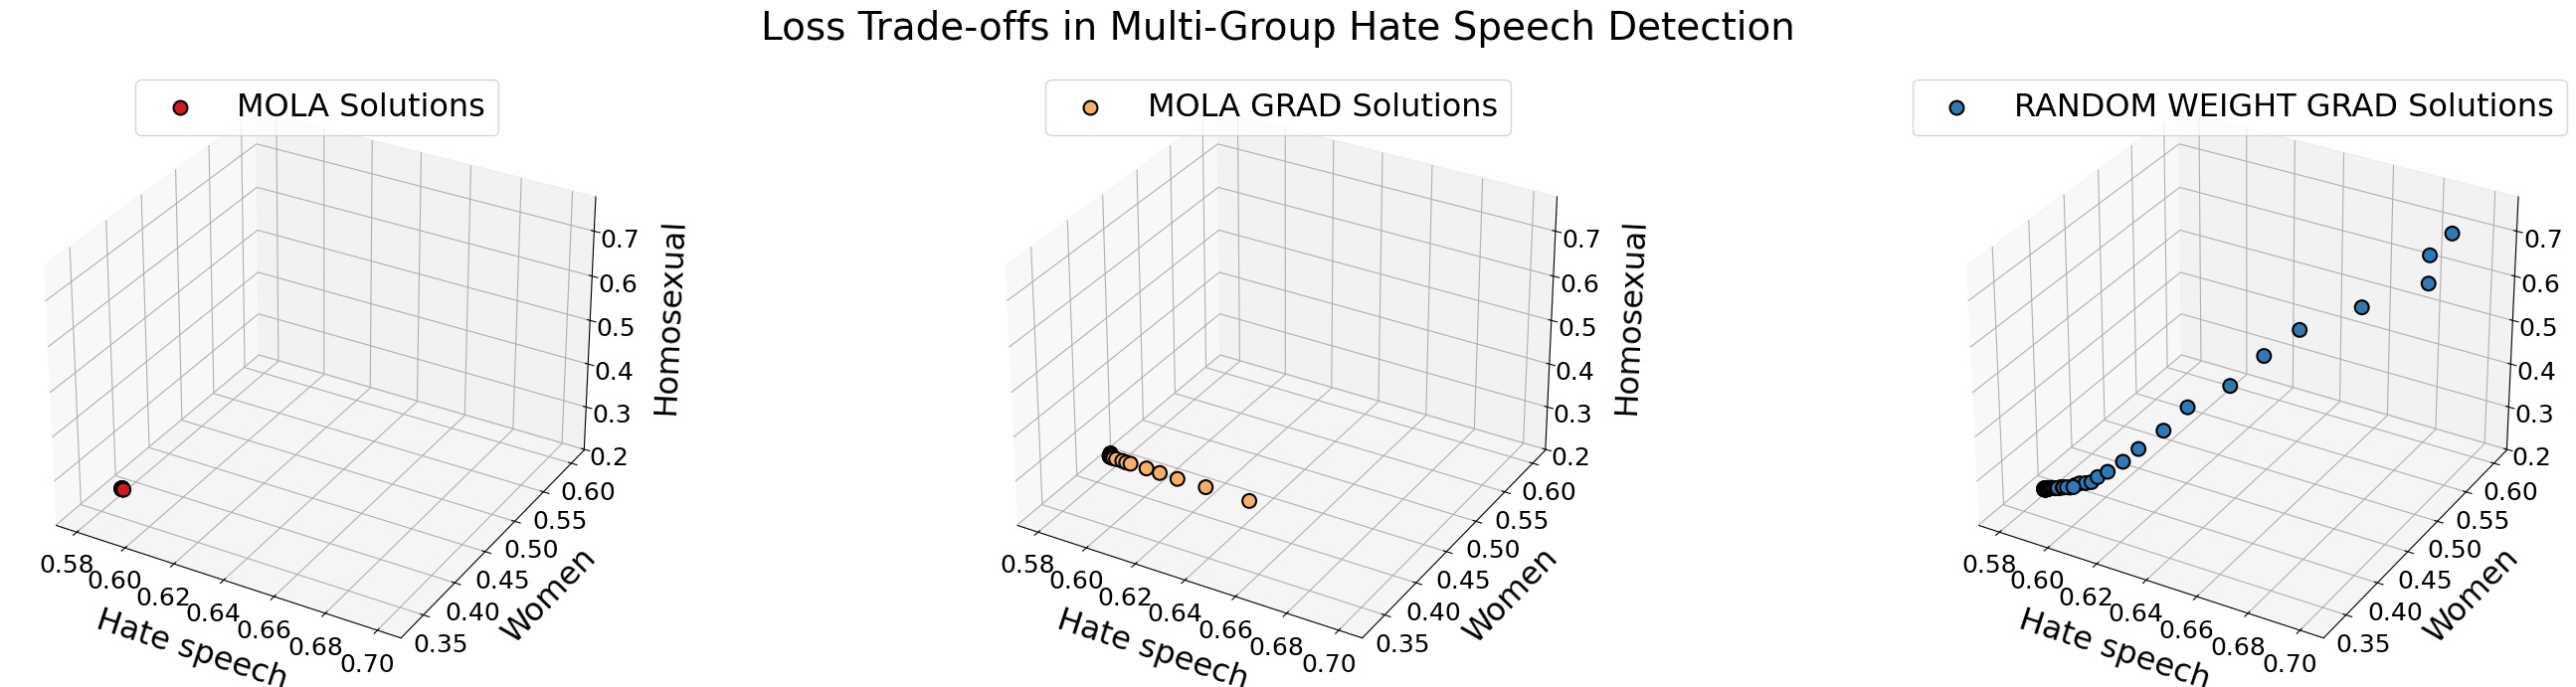

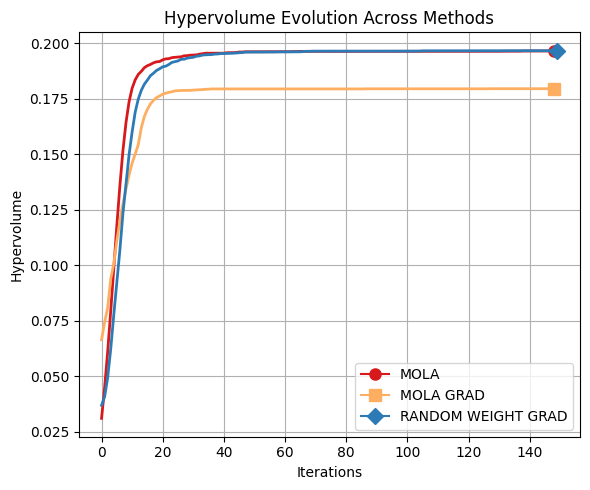

In [27]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

plot_pareto(methods=pareto_dict,
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/3_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)